# C.6 — Credit Scoring avec IA Explicable (XAI)
**ECE Paris — Ing4 — IA Probabiliste, Théorie des Jeux et ML — 2026**

---

## Plan du notebook
1. **Setup & Données** — Chargement German Credit Dataset, EDA
2. **Prétraitement** — Encodage, split, SMOTE
3. **Modèles** — XGBoost, LightGBM, Régression Logistique
4. **SHAP** — Importance globale + explications locales *(Minimum)*
5. **LIME** — Comparaison SHAP vs LIME *(Bon)*
6. **Explications Contrefactuelles** — DiCE : que changer pour être accepté ? *(Bon)*
7. **Analyse de Biais** — Âge, Genre, Disparate Impact *(Bon)*
8. **Audit Fairness** — Equalized Odds, Fairlearn *(Excellent)*
9. **Black Box vs Interprétable** — Trade-off accuracy/explicabilité *(Excellent)*
10. **Dashboard Interactif** — Gradio *(Excellent)*

> **Contexte réglementaire** : Le RGPD (Article 22) donne aux clients le droit d'obtenir une explication sur toute décision automatisée les affectant. Ce projet implémente ce droit à l'explication.

## 0. Installation des dépendances

In [1]:
# Installer toutes les dépendances nécessaires
!pip install xgboost lightgbm shap lime dice-ml fairlearn imbalanced-learn gradio plotly pandas numpy scikit-learn matplotlib seaborn --quiet

## 1. Setup & Chargement des données

In [2]:
# ============================================================
#  IMPORTS
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ML
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, f1_score,
    precision_recall_curve, average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.calibration import CalibratedClassifierCV

# Modèles boîte noire
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Rééchantillonnage
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Explainability
import shap
import lime
import lime.lime_tabular

# Fairness
from fairlearn.metrics import (
    MetricFrame, demographic_parity_difference,
    equalized_odds_difference, selection_rate
)
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds

# Affichage
from IPython.display import display, HTML

# Seed reproductibilité
SEED = 42
np.random.seed(SEED)

# Dossier de sauvegarde des figures — chemin relatif au notebook
SAVE_DIR = r"/Users/joeboueri/Desktop/Etudes/ECE/M1/Semestre 2/IA Finance/2026-ECE-ING4-Fin-IA-Projet2-Gr03"
os.makedirs(SAVE_DIR, exist_ok=True)

print("✅ Tous les imports réussis !")

✅ Tous les imports réussis !


In [3]:
# ============================================================
#  CHARGEMENT DU DATASET — German Credit (UCI)
#  1000 demandes de crédit, 20 features, cible : bon/mauvais payeur
# ============================================================
print("📥 Chargement du German Credit Dataset...")
credit = fetch_openml('credit-g', version=1, as_frame=True)
df = credit.frame

# Renommer la cible
df['target'] = (df['class'] == 'good').astype(int)  # 1 = bon crédit, 0 = mauvais
df = df.drop('class', axis=1)

print(f"✅ Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"\nDistribution de la cible:")
print(df['target'].value_counts())
print(f"\nTaux de bons crédits: {df['target'].mean():.1%}")
df.head()

📥 Chargement du German Credit Dataset...
✅ Dataset chargé : 1000 lignes, 21 colonnes

Distribution de la cible:
target
1    700
0    300
Name: count, dtype: int64

Taux de bons crédits: 70.0%


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,1
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,0
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,1
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,1
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,0


### 1.1 Analyse Exploratoire (EDA)

In [4]:
# Description des features
FEATURE_DESCRIPTIONS = {
    'checking_status': 'Statut du compte courant',
    'duration': 'Durée du crédit (mois)',
    'credit_history': 'Historique de crédit',
    'purpose': "But du crédit",
    'credit_amount': 'Montant du crédit (DM)',
    'savings_status': 'Épargne / Obligations',
    'employment': 'Durée d\'emploi actuel',
    'installment_commitment': 'Taux d\'endettement (% revenu)',
    'personal_status': 'Statut personnel & genre',
    'other_parties': 'Autres débiteurs/garants',
    'residence_since': 'Résidence actuelle depuis (ans)',
    'property_magnitude': 'Bien immobilier',
    'age': 'Âge (années)',
    'other_payment_plans': 'Autres plans de paiement',
    'housing': 'Logement',
    'existing_credits': 'Nb crédits existants',
    'job': 'Type d\'emploi',
    'num_dependents': 'Nb de personnes à charge',
    'own_telephone': 'Téléphone personnel',
    'foreign_worker': 'Travailleur étranger'
}

print("📊 Description des variables:")
for feat, desc in FEATURE_DESCRIPTIONS.items():
    dtype = df[feat].dtype
    print(f"  {feat:<30} | {desc:<40} | {dtype}")

📊 Description des variables:
  checking_status                | Statut du compte courant                 | category
  duration                       | Durée du crédit (mois)                   | int64
  credit_history                 | Historique de crédit                     | category
  purpose                        | But du crédit                            | category
  credit_amount                  | Montant du crédit (DM)                   | int64
  savings_status                 | Épargne / Obligations                    | category
  employment                     | Durée d'emploi actuel                    | category
  installment_commitment         | Taux d'endettement (% revenu)            | int64
  personal_status                | Statut personnel & genre                 | category
  other_parties                  | Autres débiteurs/garants                 | category
  residence_since                | Résidence actuelle depuis (ans)          | int64
  property_magnitude      

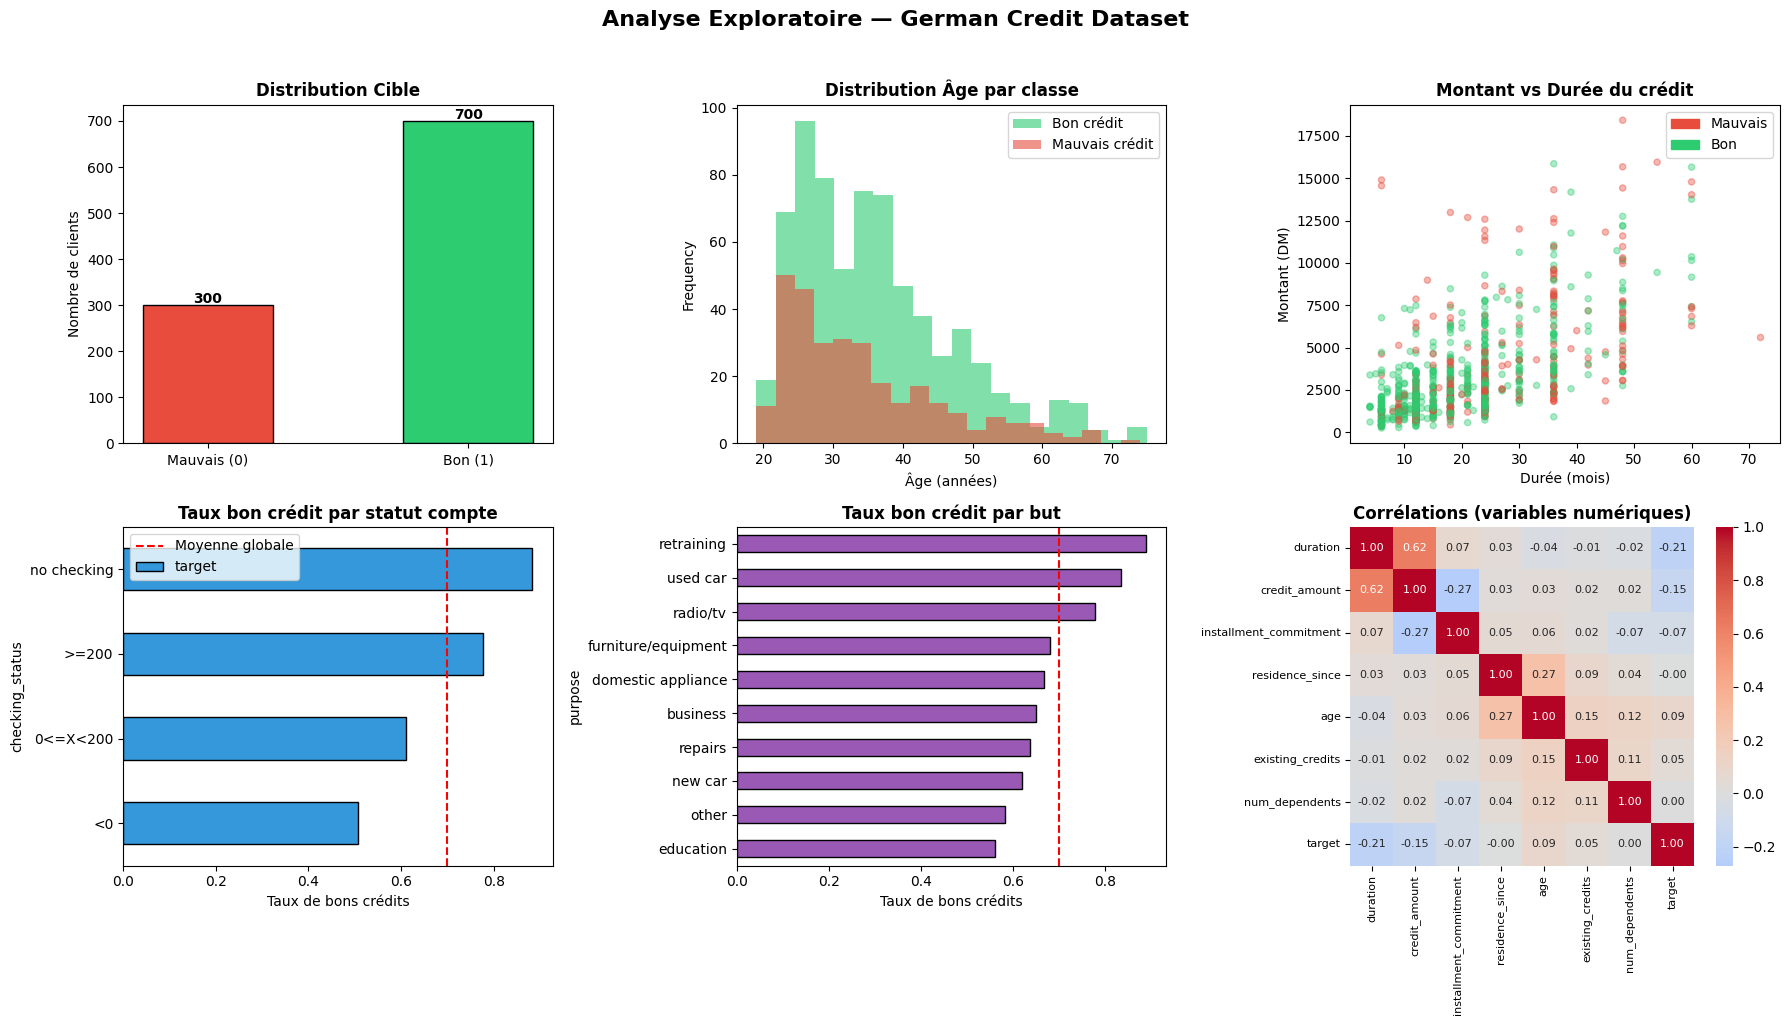

✅ EDA terminée


In [5]:
# ============================================================
#  VISUALISATION EDA
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Analyse Exploratoire — German Credit Dataset', fontsize=16, fontweight='bold', y=1.02)

# 1. Distribution de la cible
ax = axes[0, 0]
colors = ['#e74c3c', '#2ecc71']
counts = df['target'].value_counts()
ax.bar(['Mauvais (0)', 'Bon (1)'], [counts[0], counts[1]], color=colors, edgecolor='black', width=0.5)
ax.set_title('Distribution Cible', fontweight='bold')
ax.set_ylabel('Nombre de clients')
for i, v in enumerate([counts[0], counts[1]]):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2. Distribution de l'âge
ax = axes[0, 1]
df[df['target']==1]['age'].plot(kind='hist', ax=ax, alpha=0.6, color='#2ecc71', label='Bon crédit', bins=20)
df[df['target']==0]['age'].plot(kind='hist', ax=ax, alpha=0.6, color='#e74c3c', label='Mauvais crédit', bins=20)
ax.set_title('Distribution Âge par classe', fontweight='bold')
ax.set_xlabel('Âge (années)')
ax.legend()

# 3. Montant du crédit vs durée
ax = axes[0, 2]
scatter_colors = ['#e74c3c' if t == 0 else '#2ecc71' for t in df['target']]
ax.scatter(df['duration'], df['credit_amount'], c=scatter_colors, alpha=0.4, s=20)
ax.set_title('Montant vs Durée du crédit', fontweight='bold')
ax.set_xlabel('Durée (mois)')
ax.set_ylabel('Montant (DM)')
ax.legend(handles=[mpatches.Patch(color='#e74c3c', label='Mauvais'), mpatches.Patch(color='#2ecc71', label='Bon')])

# 4. Statut du compte courant
ax = axes[1, 0]
checking_rates = df.groupby('checking_status')['target'].mean().sort_values()
checking_rates.plot(kind='barh', ax=ax, color='#3498db', edgecolor='black')
ax.set_title('Taux bon crédit par statut compte', fontweight='bold')
ax.set_xlabel('Taux de bons crédits')
ax.axvline(x=df['target'].mean(), color='red', linestyle='--', label='Moyenne globale')
ax.legend()

# 5. But du crédit
ax = axes[1, 1]
purpose_rates = df.groupby('purpose')['target'].mean().sort_values()
purpose_rates.plot(kind='barh', ax=ax, color='#9b59b6', edgecolor='black')
ax.set_title('Taux bon crédit par but', fontweight='bold')
ax.set_xlabel('Taux de bons crédits')
ax.axvline(x=df['target'].mean(), color='red', linestyle='--')

# 6. Matrice de corrélation (features numériques)
ax = axes[1, 2]
num_cols = ['duration', 'credit_amount', 'installment_commitment', 'residence_since',
            'age', 'existing_credits', 'num_dependents', 'target']
corr = df[num_cols].corr()
sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0, annot=True, fmt='.2f', annot_kws={"size": 8})
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.set_title('Corrélations (variables numériques)', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'eda.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA terminée")

## 2. Prétraitement

In [6]:
# ============================================================
#  PRÉTRAITEMENT
# ============================================================
# Séparer features et cible
X = df.drop('target', axis=1)
y = df['target']

# Identifier colonnes catégorielles et numériques
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

print(f"Variables catégorielles ({len(cat_cols)}): {cat_cols}")
print(f"Variables numériques ({len(num_cols)}): {num_cols}")

# Encodage des variables catégorielles (OrdinalEncoder pour XGBoost/SHAP)
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_cat_encoded = pd.DataFrame(
    oe.fit_transform(X[cat_cols]),
    columns=cat_cols,
    index=X.index
)
X_encoded = pd.concat([X[num_cols], X_cat_encoded], axis=1)

# Garder les catégories originales pour l'interprétation
original_categories = {col: oe.categories_[i] for i, col in enumerate(cat_cols)}

# Split train/test stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"\n✅ Split effectué:")
print(f"   Train: {X_train.shape[0]} samples ({y_train.mean():.1%} positifs)")
print(f"   Test:  {X_test.shape[0]} samples ({y_test.mean():.1%} positifs)")

# Application de SMOTE sur le train set pour équilibrer les classes
smote = SMOTE(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"\n✅ Après SMOTE:")
print(f"   Train rééchantillonné: {X_train_res.shape[0]} samples")
print(f"   Distribution: {pd.Series(y_train_res).value_counts().to_dict()}")

Variables catégorielles (13): ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
Variables numériques (7): ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']

✅ Split effectué:
   Train: 800 samples (70.0% positifs)
   Test:  200 samples (70.0% positifs)

✅ Après SMOTE:
   Train rééchantillonné: 1120 samples
   Distribution: {1: 560, 0: 560}


## 3. Entraînement des modèles

In [7]:
# ============================================================
#  MODÈLES : XGBoost, LightGBM, Logistic Regression, Decision Tree
# ============================================================

# --- XGBoost (modèle principal) ---
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=SEED
)
xgb_model.fit(X_train_res, y_train_res)

# --- LightGBM ---
lgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    verbose=-1
)
lgbm_model.fit(X_train_res, y_train_res)

# --- Régression Logistique (modèle interprétable) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(C=0.1, max_iter=1000, random_state=SEED)
lr_model.fit(X_train_scaled, y_train_res)

# --- Arbre de décision (modèle interprétable) ---
dt_model = DecisionTreeClassifier(
    max_depth=5, min_samples_leaf=20, random_state=SEED
)
dt_model.fit(X_train_res, y_train_res)

print("✅ Tous les modèles entraînés !")

✅ Tous les modèles entraînés !



📊 Comparaison des performances:


,Accuracy,AUC-ROC,Avg Precision,F1-Score,Precision,Recall
Modèle,,,,,,
XGBoost,0.705,0.729,0.854,0.787,0.796,0.779
LightGBM,0.735,0.761,0.865,0.810,0.813,0.807
Logistic Regression,0.660,0.690,0.848,0.721,0.846,0.629
Decision Tree,0.685,0.729,0.849,0.749,0.847,0.671


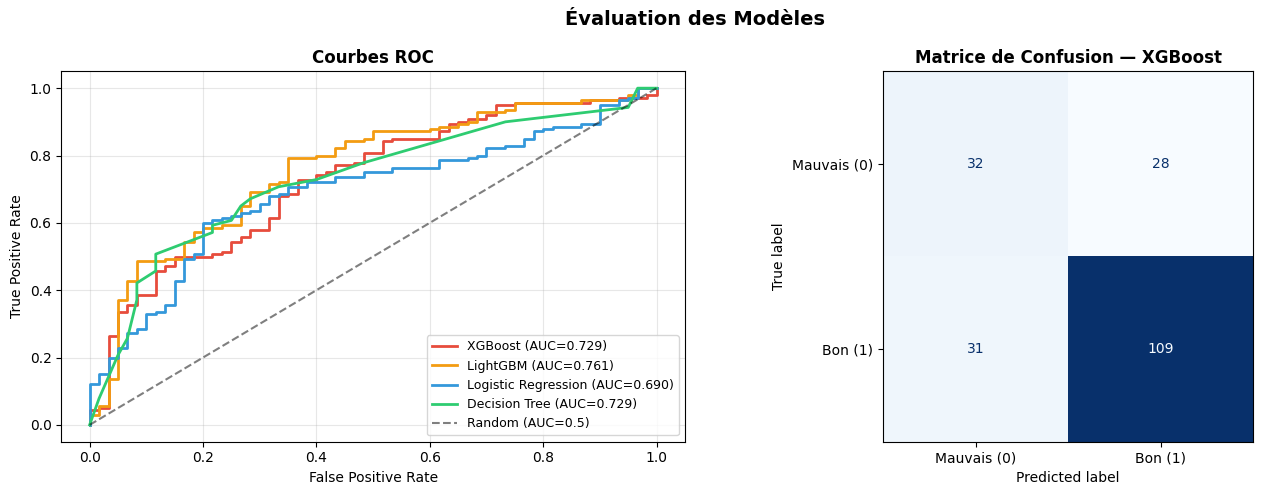

In [8]:
# ============================================================
#  ÉVALUATION COMPARATIVE DES MODÈLES
# ============================================================
def evaluate_model(model, X_test, y_test, model_name, X_test_scaled=None):
    """Évalue un modèle et retourne les métriques."""
    if model_name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    ap = average_precision_score(y_test, y_proba)
    
    report = classification_report(y_test, y_pred, output_dict=True)
    acc = report['accuracy']
    prec = report['1']['precision']
    rec = report['1']['recall']
    
    return {
        'Modèle': model_name,
        'Accuracy': f"{acc:.3f}",
        'AUC-ROC': f"{auc:.3f}",
        'Avg Precision': f"{ap:.3f}",
        'F1-Score': f"{f1:.3f}",
        'Precision': f"{prec:.3f}",
        'Recall': f"{rec:.3f}",
        '_auc': auc,
        '_proba': y_proba,
        '_pred': y_pred
    }

results = [
    evaluate_model(xgb_model, X_test, y_test, 'XGBoost', X_test_scaled),
    evaluate_model(lgbm_model, X_test, y_test, 'LightGBM', X_test_scaled),
    evaluate_model(lr_model, X_test, y_test, 'Logistic Regression', X_test_scaled),
    evaluate_model(dt_model, X_test, y_test, 'Decision Tree', X_test_scaled),
]

# Affichage tableau récap
metrics_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
print("\n📊 Comparaison des performances:")
display(metrics_df.set_index('Modèle'))

# Courbes ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Évaluation des Modèles', fontsize=14, fontweight='bold')

colors_models = {'XGBoost': '#e74c3c', 'LightGBM': '#f39c12', 
                 'Logistic Regression': '#3498db', 'Decision Tree': '#2ecc71'}

ax = axes[0]
for r in results:
    fpr, tpr, _ = roc_curve(y_test, r['_proba'])
    ax.plot(fpr, tpr, label=f"{r['Modèle']} (AUC={r['_auc']:.3f})",
            color=colors_models[r['Modèle']], linewidth=2)
ax.plot([0,1],[0,1],'k--', alpha=0.5, label='Random (AUC=0.5)')
ax.set_title('Courbes ROC', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Matrice de confusion — XGBoost
ax = axes[1]
cm = confusion_matrix(y_test, results[0]['_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Mauvais (0)', 'Bon (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de Confusion — XGBoost', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'model_evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. SHAP — Explications Globales et Locales 

**SHAP (SHapley Additive exPlanations)** est basé sur la théorie des jeux coopératifs. La valeur de Shapley d'une feature mesure sa contribution marginale moyenne à la prédiction, en tenant compte de toutes les coalitions possibles de features.

🔍 Calcul des valeurs SHAP (XGBoost)...


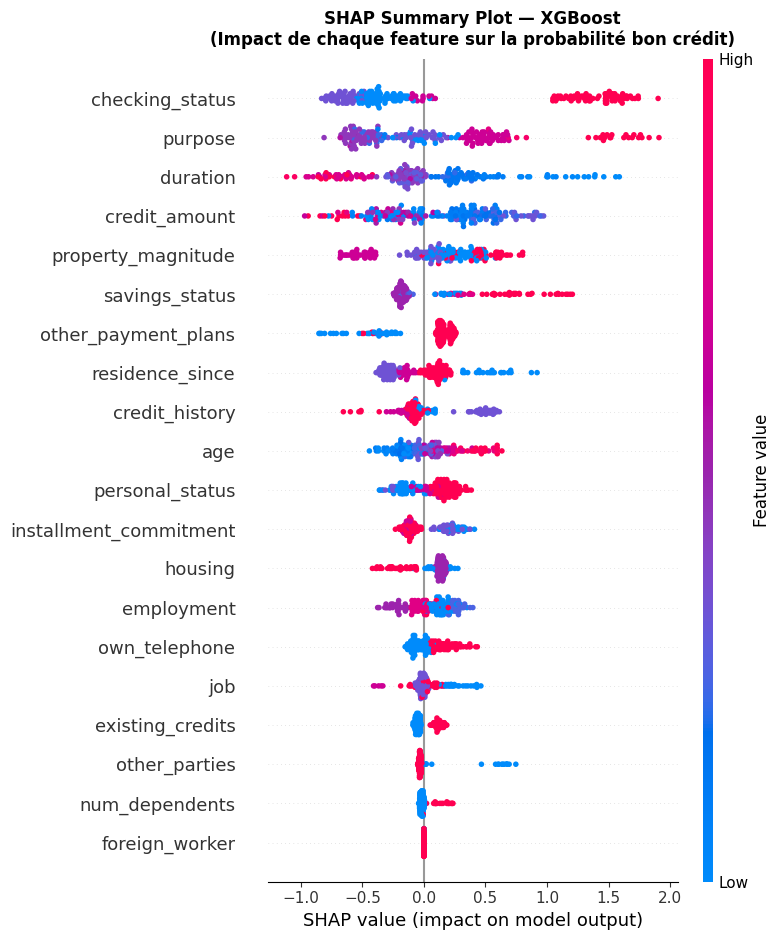

✅ SHAP Summary Plot généré


In [9]:
# ============================================================
#  SHAP — EXPLICATIONS GLOBALES (XGBoost)
# ============================================================
print("🔍 Calcul des valeurs SHAP (XGBoost)...")

# Explainer pour tree models
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb(X_test)

# Valeurs absolues pour l'importance globale
shap_values_matrix = shap_values_xgb.values

# 1. Summary plot (Beeswarm)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_matrix, X_test, 
                  feature_names=X_test.columns.tolist(),
                  max_display=20, show=False)
plt.title('SHAP Summary Plot — XGBoost\n(Impact de chaque feature sur la probabilité bon crédit)',
          fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP Summary Plot généré")

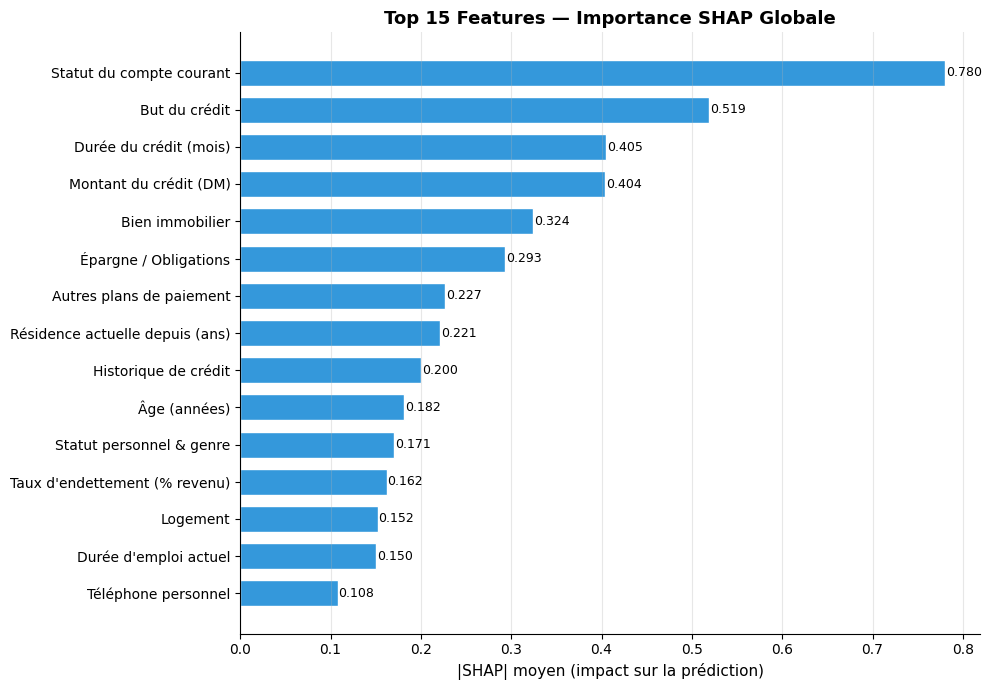


🏆 Top 5 features les plus importantes:
  Statut du compte courant                 SHAP: 0.7799
  But du crédit                            SHAP: 0.5194
  Durée du crédit (mois)                   SHAP: 0.4050
  Montant du crédit (DM)                   SHAP: 0.4037
  Bien immobilier                          SHAP: 0.3238


In [10]:
# ============================================================
#  SHAP — BAR PLOT (importance globale)
# ============================================================
mean_abs_shap = np.abs(shap_values_matrix).mean(axis=0)
feature_importance_shap = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP_importance': mean_abs_shap,
    'Description': [FEATURE_DESCRIPTIONS.get(c, c) for c in X_test.columns]
}).sort_values('SHAP_importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(feature_importance_shap['Description'][:15][::-1],
               feature_importance_shap['SHAP_importance'][:15][::-1],
               color='#3498db', edgecolor='white', height=0.7)
ax.set_title('Top 15 Features — Importance SHAP Globale', fontweight='bold', fontsize=13)
ax.set_xlabel('|SHAP| moyen (impact sur la prédiction)', fontsize=11)
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n🏆 Top 5 features les plus importantes:")
for _, row in feature_importance_shap.head(5).iterrows():
    print(f"  {row['Description']:<40} SHAP: {row['SHAP_importance']:.4f}")

🚫 CLIENT REFUSÉ — Explication locale SHAP
Probabilité bon crédit: 41.5% → REFUSÉ


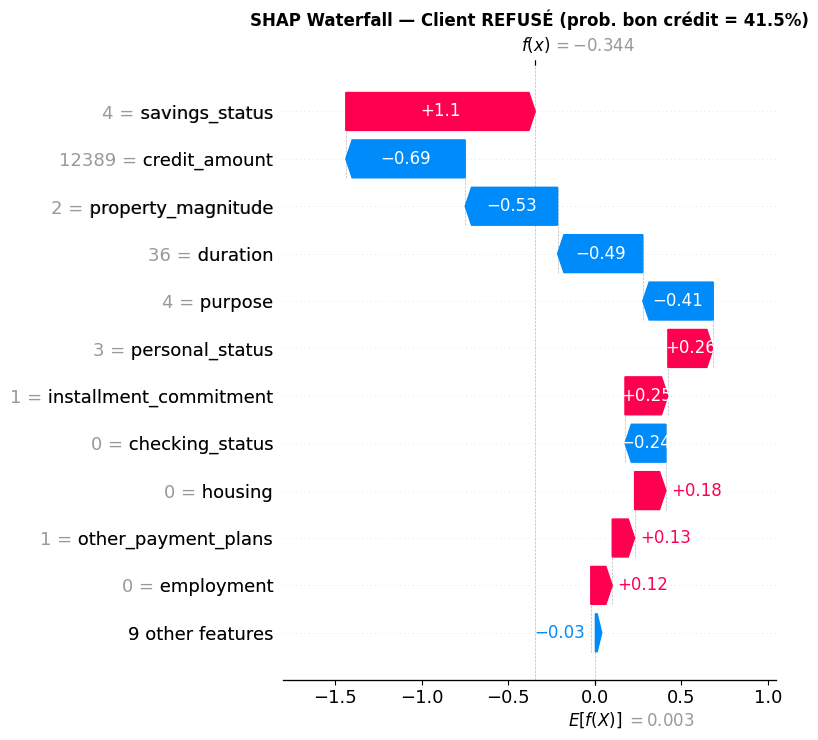


✅ CLIENT ACCEPTÉ — Explication locale SHAP
Probabilité bon crédit: 82.9% → ACCEPTÉ


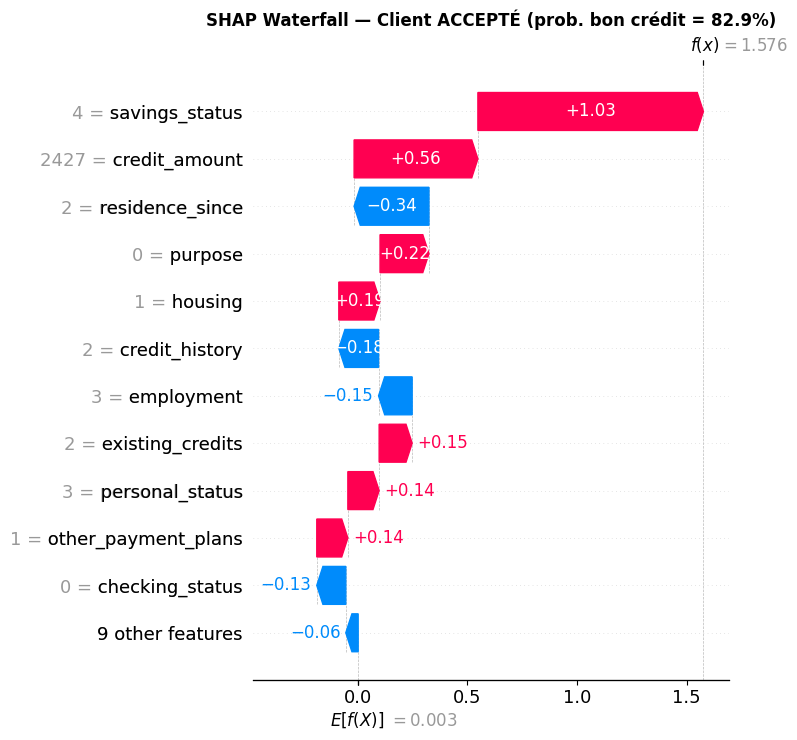

In [11]:
# ============================================================
#  SHAP — EXPLICATIONS LOCALES (individu par individu)
#  Cas 1 : Client refusé → comprendre pourquoi
#  Cas 2 : Client accepté → comprendre pourquoi
# ============================================================

# Trouver un client refusé et un client accepté
y_pred_xgb = xgb_model.predict(X_test)
refused_idx = np.where((y_pred_xgb == 0) & (y_test.values == 0))[0][0]  # vrai refus
accepted_idx = np.where((y_pred_xgb == 1) & (y_test.values == 1))[0][0]  # vrai accepté

# ---- Client refusé ----
print("=" * 60)
print("🚫 CLIENT REFUSÉ — Explication locale SHAP")
print("=" * 60)
client_refused = X_test.iloc[refused_idx:refused_idx+1]
prob_refused = xgb_model.predict_proba(client_refused)[0][1]
print(f"Probabilité bon crédit: {prob_refused:.1%} → REFUSÉ")

fig, ax = plt.subplots(figsize=(10, 4))
shap.waterfall_plot(shap_values_xgb[refused_idx], max_display=12, show=False)
plt.title(f'SHAP Waterfall — Client REFUSÉ (prob. bon crédit = {prob_refused:.1%})',
          fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_local_refused.png'), dpi=150, bbox_inches='tight')
plt.show()

# ---- Client accepté ----
print("\n" + "=" * 60)
print("✅ CLIENT ACCEPTÉ — Explication locale SHAP")
print("=" * 60)
client_accepted = X_test.iloc[accepted_idx:accepted_idx+1]
prob_accepted = xgb_model.predict_proba(client_accepted)[0][1]
print(f"Probabilité bon crédit: {prob_accepted:.1%} → ACCEPTÉ")

fig, ax = plt.subplots(figsize=(10, 4))
shap.waterfall_plot(shap_values_xgb[accepted_idx], max_display=12, show=False)
plt.title(f'SHAP Waterfall — Client ACCEPTÉ (prob. bon crédit = {prob_accepted:.1%})',
          fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_local_accepted.png'), dpi=150, bbox_inches='tight')
plt.show()

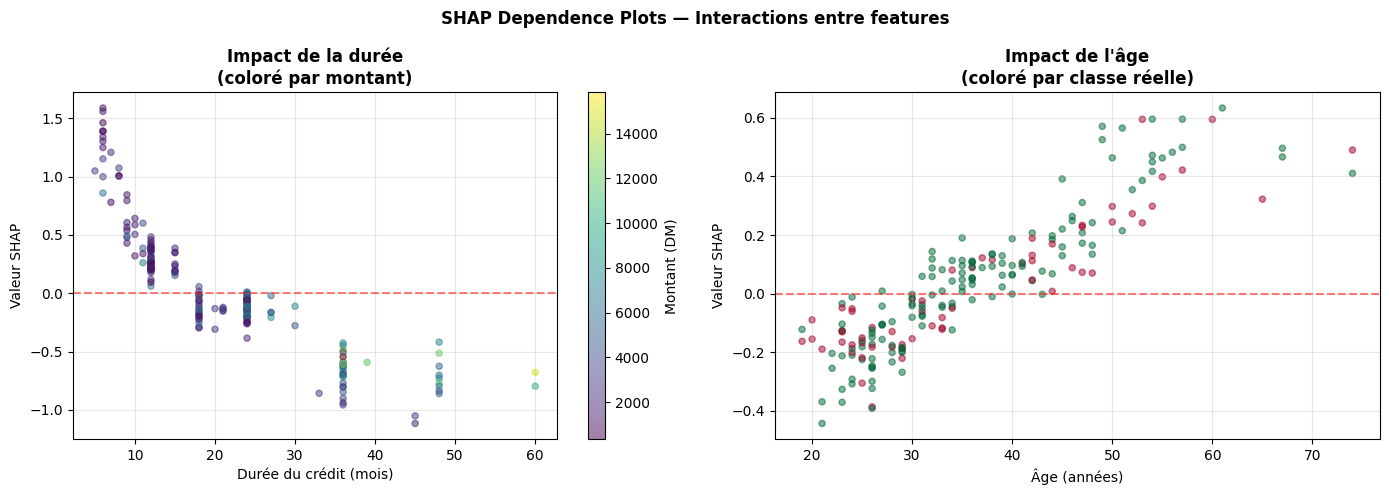

In [12]:
# ============================================================
#  SHAP — DEPENDENCE PLOTS (interactions entre features)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SHAP Dependence Plots — Interactions entre features', fontweight='bold')

# Duration vs SHAP
ax = axes[0]
checking_shap = shap_values_matrix[:, X_test.columns.get_loc('duration')]
ax.scatter(X_test['duration'], checking_shap,
           c=X_test['credit_amount'], cmap='viridis', alpha=0.5, s=20)
ax.set_xlabel('Durée du crédit (mois)')
ax.set_ylabel('Valeur SHAP')
ax.set_title('Impact de la durée\n(coloré par montant)', fontweight='bold')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.grid(alpha=0.3)
plt.colorbar(ax.collections[0], ax=ax, label='Montant (DM)')

# Age vs SHAP
ax = axes[1]
age_shap = shap_values_matrix[:, X_test.columns.get_loc('age')]
ax.scatter(X_test['age'], age_shap,
           c=y_test.values, cmap='RdYlGn', alpha=0.5, s=20)
ax.set_xlabel('Âge (années)')
ax.set_ylabel('Valeur SHAP')
ax.set_title('Impact de l\'âge\n(coloré par classe réelle)', fontweight='bold')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_dependence.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. LIME — Comparaison SHAP vs LIME

**LIME (Local Interpretable Model-agnostic Explanations)** crée un modèle linéaire local autour de chaque prédiction. Contrairement à SHAP (qui est global et cohérent), LIME est purement local et peut être instable.

🔍 Configuration de l'explainer LIME...

🚫 LIME — Client REFUSÉ:
  ↓ Défavorise    | duration > 29.00                         | -0.0560
  ↑ Favorise      | housing <= 1.00                          | +0.0384
  ↓ Défavorise    | 0.00 < own_telephone <= 1.00             | -0.0377
  ↑ Favorise      | job <= 1.00                              | +0.0364
  ↑ Favorise      | employment <= 0.00                       | +0.0336
  ↑ Favorise      | savings_status > 2.00                    | +0.0319
  ↓ Défavorise    | 3.00 < residence_since <= 4.00           | -0.0269
  ↑ Favorise      | installment_commitment <= 2.00           | +0.0233
  ↓ Défavorise    | 3.00 < purpose <= 4.00                   | -0.0225
  ↓ Défavorise    | 1.00 < property_magnitude <= 2.51        | -0.0216


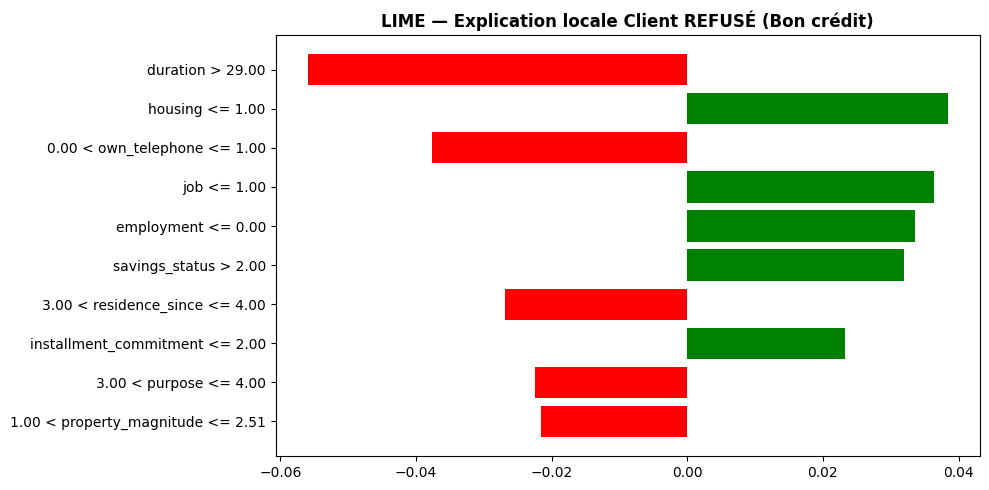

In [13]:
# ============================================================
#  LIME — Explication locale
# ============================================================
print("🔍 Configuration de l'explainer LIME...")

# Configurer LIME
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_res.values,
    feature_names=X_test.columns.tolist(),
    class_names=['Mauvais crédit', 'Bon crédit'],
    mode='classification',
    random_state=SEED
)

# Explication du client refusé
lime_exp_refused = lime_explainer.explain_instance(
    data_row=X_test.iloc[refused_idx].values,
    predict_fn=xgb_model.predict_proba,
    num_features=10,
    num_samples=1000
)

print("\n🚫 LIME — Client REFUSÉ:")
lime_features_refused = lime_exp_refused.as_list(label=1)
for feat, weight in lime_features_refused:
    direction = '↑ Favorise' if weight > 0 else '↓ Défavorise'
    print(f"  {direction:15} | {feat:<40} | {weight:+.4f}")

# Visualisation LIME
fig = lime_exp_refused.as_pyplot_figure(label=1)
fig.set_size_inches(10, 5)
plt.title('LIME — Explication locale Client REFUSÉ (Bon crédit)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'lime_refused.png'), dpi=150, bbox_inches='tight')
plt.show()

📊 Comparaison SHAP vs LIME pour le client refusé


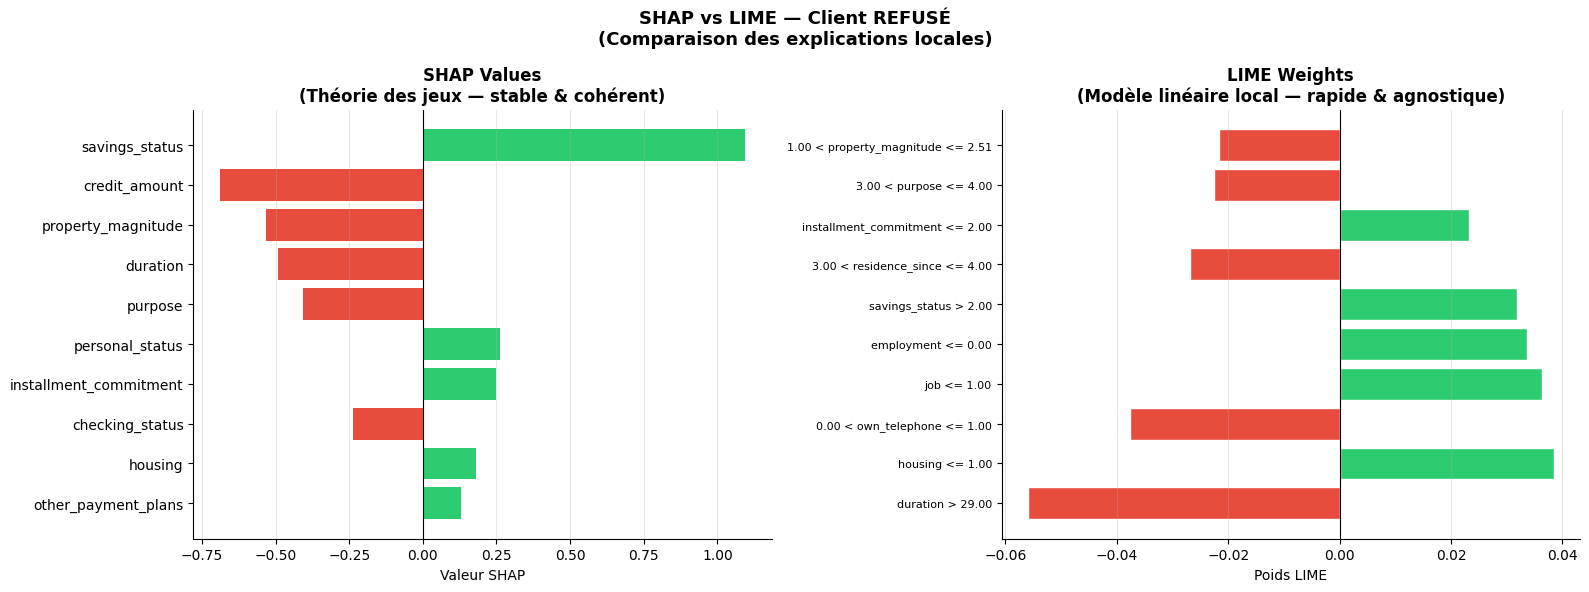


📝 Synthèse SHAP vs LIME:
+----------------------------------------------------------+
| Critère              | SHAP             | LIME             |
+----------------------------------------------------------+
| Fondement            | Théorie des jeux | Régression locale |
| Portée               | Global + Local   | Local seulement  |
| Cohérence            | ✅ Garantie       | ❌ Non garantie   |
| Stabilité            | ✅ Stable         | ⚠️ Variable      |
| Vitesse              | Lent (TreeSHAP:OK) | ✅ Rapide         |
| Interprétation       | Valeur marginale | Règle linéaire   |
+----------------------------------------------------------+


In [14]:
# ============================================================
#  COMPARAISON SHAP vs LIME — Même client, même modèle
# ============================================================
print("📊 Comparaison SHAP vs LIME pour le client refusé")
print("=" * 60)

# SHAP features
shap_vals_refused = shap_values_matrix[refused_idx]
shap_feat_df = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP_value': shap_vals_refused
}).sort_values('SHAP_value', key=abs, ascending=False).head(10)

# LIME features
lime_dict = dict(lime_features_refused)
lime_feat_df = pd.DataFrame([
    {'Feature_raw': k, 'LIME_value': v} for k, v in lime_dict.items()
])

# Visualisation côte à côte
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SHAP vs LIME — Client REFUSÉ\n(Comparaison des explications locales)',
             fontweight='bold', fontsize=13)

# SHAP
ax = axes[0]
top10 = shap_feat_df.head(10)
colors_shap = ['#e74c3c' if v < 0 else '#2ecc71' for v in top10['SHAP_value']]
bars = ax.barh(top10['Feature'][::-1], top10['SHAP_value'][::-1], color=colors_shap[::-1])
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('SHAP Values\n(Théorie des jeux — stable & cohérent)', fontweight='bold')
ax.set_xlabel('Valeur SHAP')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# LIME
ax = axes[1]
lime_top = lime_feat_df.head(10)
colors_lime = ['#e74c3c' if v < 0 else '#2ecc71' for v in lime_top['LIME_value']]
ax.barh(range(len(lime_top)), lime_top['LIME_value'].values,
        color=colors_lime, edgecolor='white')
ax.set_yticks(range(len(lime_top)))
ax.set_yticklabels([t[:35] for t in lime_top['Feature_raw']], fontsize=8)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('LIME Weights\n(Modèle linéaire local — rapide & agnostique)', fontweight='bold')
ax.set_xlabel('Poids LIME')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shap_vs_lime.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n📝 Synthèse SHAP vs LIME:")
print("+" + "-"*58 + "+")
print(f"| {'Critère':<20} | {'SHAP':<16} | {'LIME':<16} |")
print("+" + "-"*58 + "+")
comparisons = [
    ("Fondement", "Théorie des jeux", "Régression locale"),
    ("Portée", "Global + Local", "Local seulement"),
    ("Cohérence", "✅ Garantie", "❌ Non garantie"),
    ("Stabilité", "✅ Stable", "⚠️ Variable"),
    ("Vitesse", "Lent (TreeSHAP:OK)", "✅ Rapide"),
    ("Interprétation", "Valeur marginale", "Règle linéaire"),
]
for c, s, l in comparisons:
    print(f"| {c:<20} | {s:<16} | {l:<16} |")
print("+" + "-"*58 + "+")

## 6. Explications Contrefactuelles — DiCE

**Question clé** : *"Que dois-je changer pour que ma demande de crédit soit acceptée ?"*

Les contrefactuels génèrent des scénarios alternatifs minimaux — le minimum de changements pour inverser la décision.

In [15]:
# ============================================================
#  COUNTERFACTUALS — DiCE
# ============================================================
import dice_ml

# Préparer les données pour DiCE
X_train_dice = X_train_res.copy()
X_train_dice['target'] = y_train_res.values

# Définir les features continues et catégorielles
continuous_features = num_cols

d = dice_ml.Data(
    dataframe=X_train_dice,
    continuous_features=continuous_features,
    outcome_name='target'
)

m = dice_ml.Model(model=xgb_model, backend='sklearn')
exp = dice_ml.Dice(d, m, method='random')

# Générer des contrefactuels pour le client refusé
print("🔄 Génération des explications contrefactuelles...")
print(f"Client refusé (prob. bon crédit = {prob_refused:.1%})")
print("\nProfil du client refusé:")

client_profile = X_test.iloc[refused_idx]
for feat in ['duration', 'credit_amount', 'age', 'checking_status', 'savings_status']:
    print(f"  {FEATURE_DESCRIPTIONS.get(feat, feat)}: {client_profile[feat]}")

# Générer les contrefactuels
query_instance = X_test.iloc[refused_idx:refused_idx+1]

cf_explanations = exp.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_class="opposite",
    features_to_vary=['duration', 'credit_amount', 'installment_commitment',
                      'residence_since', 'age', 'existing_credits']
)

print("\n✅ Contrefactuels générés !")
cf_explanations.visualize_as_dataframe(show_only_changes=True)

🔄 Génération des explications contrefactuelles...
Client refusé (prob. bon crédit = 41.5%)

Profil du client refusé:
  Durée du crédit (mois): 36.0
  Montant du crédit (DM): 12389.0
  Âge (années): 37.0
  Statut du compte courant: 0.0
  Épargne / Obligations: 4.0


100%|██████████| 1/1 [00:00<00:00, 16.92it/s]


✅ Contrefactuels générés !
Query instance (original outcome : 0)


,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,checking_status,credit_history,purpose,...,employment,personal_status,other_parties,property_magnitude,other_payment_plans,housing,job,own_telephone,foreign_worker,target
0,36,12389,1,4,37,1,1,0.0,3.0,4.0,...,0.0,3.0,2.0,2.0,1.0,0.0,1.0,1.0,1.0,0



Diverse Counterfactual set (new outcome: 1)


,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,checking_status,credit_history,purpose,...,employment,personal_status,other_parties,property_magnitude,other_payment_plans,housing,job,own_telephone,foreign_worker,target
0,14.0,-,-,1.0,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0
1,-,-,-,-,-,3.0,-,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0
2,-,-,-,-,-,2.0,-,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0


In [16]:
# ============================================================
#  VISUALISATION CONTREFACTUELS — Format compréhensible
# ============================================================
print("📋 RAPPORT CONTREFACTUEL — Que changer pour être accepté ?")
print("=" * 65)
print(f"\nProfil actuel → REFUSÉ (score: {prob_refused:.1%})")
print("-" * 65)

# Récupérer les CF
cf_df = cf_explanations.cf_examples_list[0].final_cfs_df
original = query_instance.iloc[0]

for i, (_, cf) in enumerate(cf_df.iterrows()):
    print(f"\n🎯 Scénario alternatif #{i+1} → ACCEPTÉ")
    changes_found = False
    for feat in X_test.columns:
        orig_val = original[feat]
        cf_val = cf[feat] if feat in cf.index else orig_val
        if abs(float(orig_val) - float(cf_val)) > 0.01:
            desc = FEATURE_DESCRIPTIONS.get(feat, feat)
            print(f"   ✏️  {desc:<35}: {orig_val:.1f} → {cf_val:.1f}")
            changes_found = True
    if not changes_found:
        print("   (Aucun changement détecté dans ce scénario)")

print("\n" + "=" * 65)
print("💡 Interprétation : Ces changements sont les MINIMAUX nécessaires")
print("   pour inverser la décision du modèle (REFUSÉ → ACCEPTÉ).")

📋 RAPPORT CONTREFACTUEL — Que changer pour être accepté ?

Profil actuel → REFUSÉ (score: 41.5%)
-----------------------------------------------------------------

🎯 Scénario alternatif #1 → ACCEPTÉ
   ✏️  Durée du crédit (mois)             : 36.0 → 14.0
   ✏️  Résidence actuelle depuis (ans)    : 4.0 → 1.0

🎯 Scénario alternatif #2 → ACCEPTÉ
   ✏️  Montant du crédit (DM)             : 12389.0 → 5967.0
   ✏️  Nb crédits existants               : 1.0 → 3.0

🎯 Scénario alternatif #3 → ACCEPTÉ
   ✏️  Montant du crédit (DM)             : 12389.0 → 972.0
   ✏️  Nb crédits existants               : 1.0 → 2.0

💡 Interprétation : Ces changements sont les MINIMAUX nécessaires
   pour inverser la décision du modèle (REFUSÉ → ACCEPTÉ).


## 7. Analyse de Biais — Âge & Genre 

Conformément au RGPD et à la directive européenne anti-discrimination, nous analysons si le modèle traite équitablement différents groupes démographiques.

In [17]:
# ============================================================
#  ANALYSE DE BIAIS — Âge & Genre
# ============================================================

# Créer un dataframe d'analyse avec les prédictions
bias_df = X_test.copy()
bias_df['target'] = y_test.values
bias_df['y_pred'] = xgb_model.predict(X_test)
bias_df['y_proba'] = xgb_model.predict_proba(X_test)[:, 1]

# --- ANALYSE PAR ÂGE ---
# Créer des tranches d'âge
bias_df['age_group'] = pd.cut(
    bias_df['age'],
    bins=[0, 25, 35, 45, 60, 100],
    labels=['<25 ans', '25-35 ans', '35-45 ans', '45-60 ans', '>60 ans']
)

# Métriques par tranche d'âge
age_metrics = bias_df.groupby('age_group').agg(
    n_clients=('target', 'count'),
    taux_reel_bon=('target', 'mean'),
    taux_predit_bon=('y_pred', 'mean'),
    score_moyen=('y_proba', 'mean')
).round(3)

# AUC par groupe d'âge
def auc_group(group):
    if len(group['target'].unique()) > 1:
        return roc_auc_score(group['target'], group['y_proba'])
    return np.nan

age_auc = bias_df.groupby('age_group').apply(auc_group)
age_metrics['AUC'] = age_auc.values

print("📊 Métriques par tranche d'âge:")
display(age_metrics)

# --- ANALYSE PAR GENRE ---
# Dans German Credit, personal_status contient genre + statut marital
# Extraire le genre approximatif
gender_map = {
    0.0: 'Homme (marié/divorcé)',  # 'male div/sep'
    1.0: 'Femme (non-mariée)',      # 'female div/dep/mar'
    2.0: 'Homme (célibataire)',     # 'male single'
    3.0: 'Homme (marié/vef)',       # 'male mar/wid'
    4.0: 'Femme (célibataire)'      # 'female single'
}
bias_df['genre_group'] = bias_df['personal_status'].map(
    lambda x: 'Femme' if x in [1.0, 4.0] else 'Homme'
)

gender_metrics = bias_df.groupby('genre_group').agg(
    n_clients=('target', 'count'),
    taux_reel_bon=('target', 'mean'),
    taux_predit_bon=('y_pred', 'mean'),
    score_moyen=('y_proba', 'mean')
).round(3)

gender_auc = bias_df.groupby('genre_group').apply(auc_group)
gender_metrics['AUC'] = gender_auc.values

print("\n📊 Métriques par genre:")
display(gender_metrics)

📊 Métriques par tranche d'âge:


,n_clients,taux_reel_bon,taux_predit_bon,score_moyen,AUC
age_group,,,,,
<25 ans,35,0.543,0.571,0.579,0.549342
25-35 ans,76,0.763,0.697,0.649,0.763410
35-45 ans,46,0.783,0.739,0.684,0.691667
45-60 ans,37,0.622,0.676,0.658,0.804348
>60 ans,6,0.667,0.833,0.837,0.875000



📊 Métriques par genre:


,n_clients,taux_reel_bon,taux_predit_bon,score_moyen,AUC
genre_group,,,,,
Femme,8,0.375,0.375,0.476,0.666667
Homme,192,0.714,0.698,0.660,0.719575


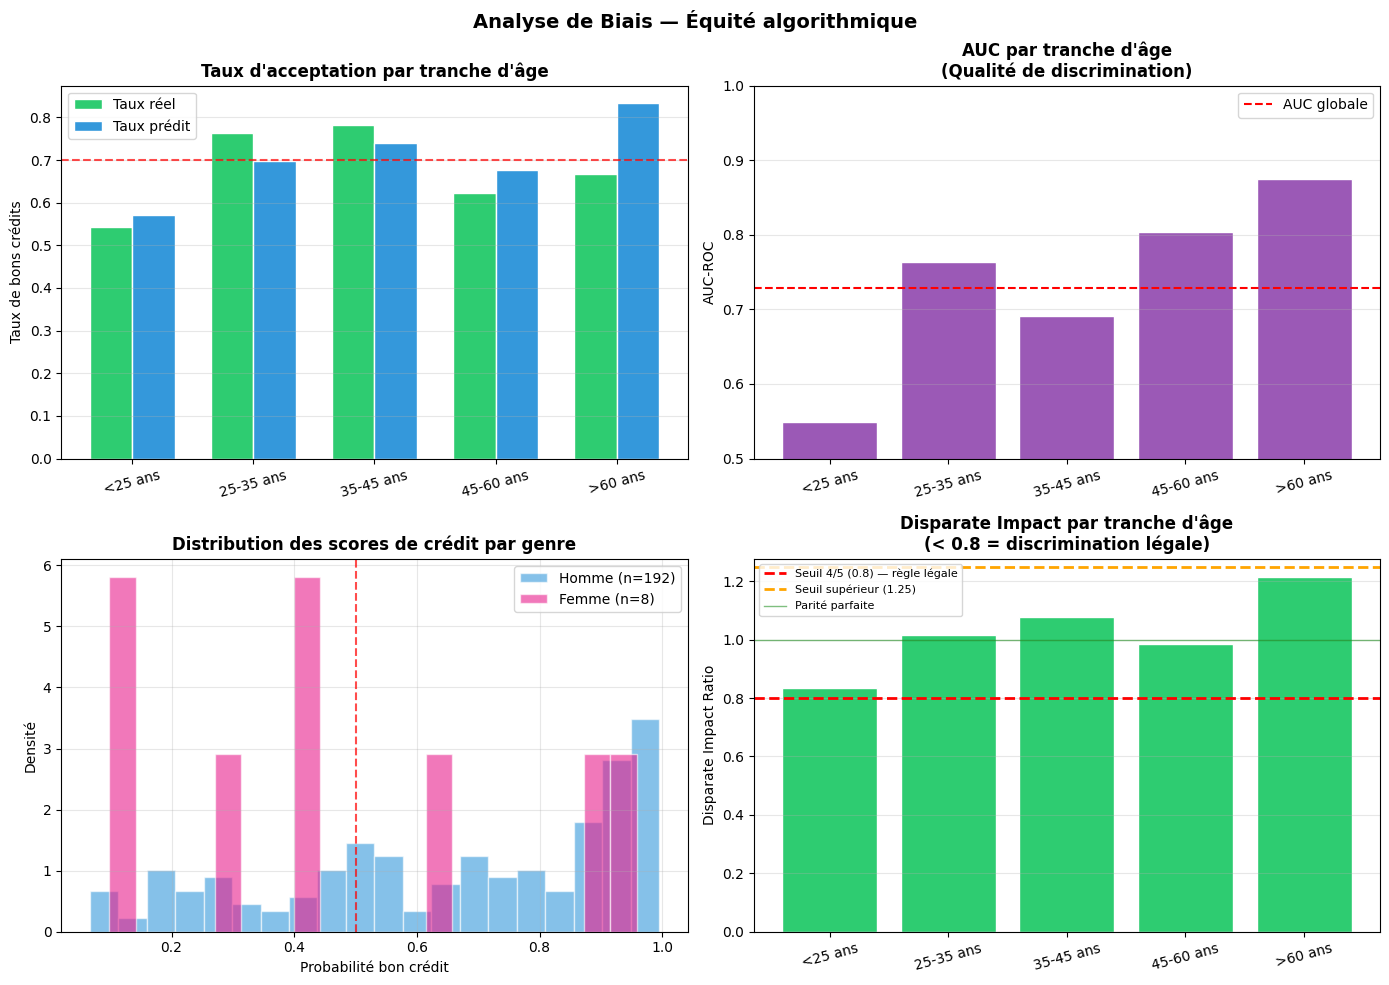


📋 RAPPORT DE BIAIS:
  <25 ans         | Disparate Impact: 0.834 | ✅ OK
  25-35 ans       | Disparate Impact: 1.018 | ✅ OK
  35-45 ans       | Disparate Impact: 1.079 | ✅ OK
  45-60 ans       | Disparate Impact: 0.987 | ✅ OK
  >60 ans         | Disparate Impact: 1.216 | ✅ OK


In [18]:
# ============================================================
#  VISUALISATION DES BIAIS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analyse de Biais — Équité algorithmique', fontsize=14, fontweight='bold')

# 1. Taux d'acceptation par tranche d'âge
ax = axes[0, 0]
x = np.arange(len(age_metrics))
w = 0.35
ax.bar(x - w/2, age_metrics['taux_reel_bon'], w, label='Taux réel', color='#2ecc71', edgecolor='white')
ax.bar(x + w/2, age_metrics['taux_predit_bon'], w, label='Taux prédit', color='#3498db', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(age_metrics.index, rotation=15)
ax.set_title('Taux d\'acceptation par tranche d\'âge', fontweight='bold')
ax.set_ylabel('Taux de bons crédits')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=bias_df['target'].mean(), color='red', linestyle='--', alpha=0.7, label='Moyenne globale')

# 2. AUC par tranche d'âge
ax = axes[0, 1]
age_auc_vals = age_metrics['AUC'].dropna()
ax.bar(age_auc_vals.index, age_auc_vals.values, color='#9b59b6', edgecolor='white')
ax.set_title('AUC par tranche d\'âge\n(Qualité de discrimination)', fontweight='bold')
ax.set_ylabel('AUC-ROC')
ax.set_ylim(0.5, 1.0)
ax.axhline(y=roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]),
           color='red', linestyle='--', label='AUC globale')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=15)

# 3. Distribution des scores par genre
ax = axes[1, 0]
for genre, color in [('Homme', '#3498db'), ('Femme', '#e91e8c')]:
    scores = bias_df[bias_df['genre_group']==genre]['y_proba']
    ax.hist(scores, bins=20, alpha=0.6, color=color, label=f'{genre} (n={len(scores)})',
            edgecolor='white', density=True)
ax.set_title('Distribution des scores de crédit par genre', fontweight='bold')
ax.set_xlabel('Probabilité bon crédit')
ax.set_ylabel('Densité')
ax.legend()
ax.grid(alpha=0.3)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Seuil décision')

# 4. Disparate Impact
ax = axes[1, 1]
age_groups = age_metrics.index.tolist()
global_rate = bias_df['y_pred'].mean()
age_pred_rates = age_metrics['taux_predit_bon'].values
disparate_impact = age_pred_rates / global_rate

colors_di = ['#e74c3c' if di < 0.8 or di > 1.25 else '#2ecc71' for di in disparate_impact]
ax.bar(age_groups, disparate_impact, color=colors_di, edgecolor='white')
ax.axhline(y=0.8, color='red', linestyle='--', linewidth=2, label='Seuil 4/5 (0.8) — règle légale')
ax.axhline(y=1.25, color='orange', linestyle='--', linewidth=2, label='Seuil supérieur (1.25)')
ax.axhline(y=1.0, color='green', linestyle='-', linewidth=1, alpha=0.5, label='Parité parfaite')
ax.set_title('Disparate Impact par tranche d\'âge\n(< 0.8 = discrimination légale)', fontweight='bold')
ax.set_ylabel('Disparate Impact Ratio')
ax.tick_params(axis='x', rotation=15)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'bias_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

# Rapport synthétique
print("\n📋 RAPPORT DE BIAIS:")
for i, (group, di) in enumerate(zip(age_groups, disparate_impact)):
    status = "⚠️ DISCRIMINATION" if di < 0.8 else "✅ OK"
    print(f"  {group:<15} | Disparate Impact: {di:.3f} | {status}")

## 8. Audit de Fairness — Fairlearn

**Equalized Odds** : Un modèle équitable doit avoir les mêmes taux de vrais positifs ET de faux positifs pour tous les groupes démographiques.

In [19]:
# ============================================================
#  AUDIT FAIRNESS — Fairlearn
# ============================================================

# Groupe sensible : âge (jeunes < 30 vs autres)
sensitive_feature_age = (X_test['age'] < 30).map({True: 'Jeune (<30)', False: 'Senior (≥30)'}).to_numpy()
sensitive_feature_gender = bias_df['genre_group'].reset_index(drop=True).values

y_pred_xgb_test = xgb_model.predict(X_test)
y_proba_xgb_test = xgb_model.predict_proba(X_test)[:, 1]

# ---- Métriques de fairness ----
print("📊 AUDIT FAIRNESS — Métriques Fairlearn")
print("=" * 65)

# 1. Demographic Parity
dp_diff_age = demographic_parity_difference(
    y_test, y_pred_xgb_test,
    sensitive_features=sensitive_feature_age
)

# 2. Equalized Odds
eo_diff_age = equalized_odds_difference(
    y_test, y_pred_xgb_test,
    sensitive_features=sensitive_feature_age
)

dp_diff_gender = demographic_parity_difference(
    y_test, y_pred_xgb_test,
    sensitive_features=sensitive_feature_gender
)

eo_diff_gender = equalized_odds_difference(
    y_test, y_pred_xgb_test,
    sensitive_features=sensitive_feature_gender
)

print(f"\n📌 Variable sensible : ÂGE (Jeune vs Senior)")
print(f"   Demographic Parity Difference : {dp_diff_age:+.4f}")
print(f"   {'✅ OK (< 0.1)' if abs(dp_diff_age) < 0.1 else '⚠️ Biais détecté (> 0.1)'}")
print(f"   Equalized Odds Difference     : {eo_diff_age:+.4f}")
print(f"   {'✅ OK (< 0.1)' if abs(eo_diff_age) < 0.1 else '⚠️ Biais détecté (> 0.1)'}")

print(f"\n📌 Variable sensible : GENRE")
print(f"   Demographic Parity Difference : {dp_diff_gender:+.4f}")
print(f"   {'✅ OK (< 0.1)' if abs(dp_diff_gender) < 0.1 else '⚠️ Biais détecté (> 0.1)'}")
print(f"   Equalized Odds Difference     : {eo_diff_gender:+.4f}")
print(f"   {'✅ OK (< 0.1)' if abs(eo_diff_gender) < 0.1 else '⚠️ Biais détecté (> 0.1)'}")

# MetricFrame pour analyse détaillée
from sklearn.metrics import accuracy_score, recall_score, precision_score

metrics_fairness = {
    'accuracy': accuracy_score,
    'precision': precision_score,
    'recall (TPR)': recall_score,
    'selection_rate': selection_rate,
}

mf_age = MetricFrame(
    metrics=metrics_fairness,
    y_true=y_test,
    y_pred=y_pred_xgb_test,
    sensitive_features=sensitive_feature_age
)

print("\n📊 MetricFrame par groupe d'âge:")
display(mf_age.by_group)

📊 AUDIT FAIRNESS — Métriques Fairlearn

📌 Variable sensible : ÂGE (Jeune vs Senior)
   Demographic Parity Difference : +0.1386
   ⚠️ Biais détecté (> 0.1)
   Equalized Odds Difference     : +0.1977
   ⚠️ Biais détecté (> 0.1)

📌 Variable sensible : GENRE
   Demographic Parity Difference : +0.3229
   ⚠️ Biais détecté (> 0.1)
   Equalized Odds Difference     : +0.2909
   ⚠️ Biais détecté (> 0.1)

📊 MetricFrame par groupe d'âge:


,accuracy,precision,recall (TPR),selection_rate
sensitive_feature_0,,,,
Jeune (<30),0.594203,0.707317,0.644444,0.594203
Senior (≥30),0.763359,0.833333,0.842105,0.732824


In [20]:
# ============================================================
#  MITIGATION DU BIAIS — Threshold par groupe (manuel)
#  Même concept que ThresholdOptimizer, sans le bug Fairlearn
# ============================================================
print("🔧 Mitigation du biais — Seuil par groupe")
print("Contrainte : Equalized Odds\n")

y_proba_test = xgb_model.predict_proba(X_test)[:, 1]
y_test_arr   = y_test.values
young_mask   = sensitive_feature_age == 'Jeune (<30)'

# Chercher les seuils optimaux par groupe
best_eo, best_ty, best_ts = 999, 0.5, 0.5
for t_young in np.arange(0.25, 0.75, 0.05):
    for t_senior in np.arange(0.25, 0.75, 0.05):
        y_tmp = np.where(young_mask,
                         (y_proba_test >= t_young).astype(int),
                         (y_proba_test >= t_senior).astype(int))
        eo = equalized_odds_difference(y_test_arr, y_tmp,
                                       sensitive_features=sensitive_feature_age)
        if abs(eo) < abs(best_eo):
            best_eo, best_ty, best_ts = eo, t_young, t_senior
            y_pred_mitigated = y_tmp

print(f"Seuil optimal — Jeunes : {best_ty:.2f} | Seniors : {best_ts:.2f}")

# Comparer avant/après
eo_before  = equalized_odds_difference(y_test_arr, y_pred_xgb_test,
                                        sensitive_features=sensitive_feature_age)
acc_before = accuracy_score(y_test_arr, y_pred_xgb_test)
acc_after  = accuracy_score(y_test_arr, y_pred_mitigated)

print(f"\n📊 Avant mitigation:")
print(f"   Accuracy:          {acc_before:.3f}")
print(f"   Equalized Odds Δ: {eo_before:.4f}")
print(f"\n📊 Après mitigation (seuil par groupe):")
print(f"   Accuracy:          {acc_after:.3f} (Δ = {acc_after - acc_before:+.3f})")
print(f"   Equalized Odds Δ: {best_eo:.4f} (Δ = {best_eo - eo_before:+.4f})")
print(f"\n💡 Trade-off: Gain équité = {eo_before - best_eo:.4f} | Coût accuracy = {acc_before - acc_after:.3f}")

🔧 Mitigation du biais — Seuil par groupe
Contrainte : Equalized Odds

Seuil optimal — Jeunes : 0.45 | Seniors : 0.40

📊 Avant mitigation:
   Accuracy:          0.705
   Equalized Odds Δ: 0.1977

📊 Après mitigation (seuil par groupe):
   Accuracy:          0.720 (Δ = +0.015)
   Equalized Odds Δ: 0.0737 (Δ = -0.1240)

💡 Trade-off: Gain équité = 0.1240 | Coût accuracy = -0.015


## 9. Black Box vs Interprétable

Comparaison du trade-off précision/explicabilité : XGBoost (boîte noire) vs Régression Logistique et Arbre de Décision (modèles interprétables).

📊 Comparaison : Boîte Noire vs Interprétable


,Modèle,Type,AUC-ROC,Accuracy,Nb paramètres,Explicabilité,Conformité RGPD
0,XGBoost,Boîte Noire,0.729,0.705,~300 arbres,4,Partielle (SHAP)
1,LightGBM,Boîte Noire,0.761,0.735,~300 arbres,4,Partielle (SHAP)
2,Régression Logistique,Interprétable,0.690,0.660,20 coefs,10,✅ Directe
3,Arbre de Décision (d=5),Interprétable,0.729,0.685,arbre d=5,9,✅ Directe


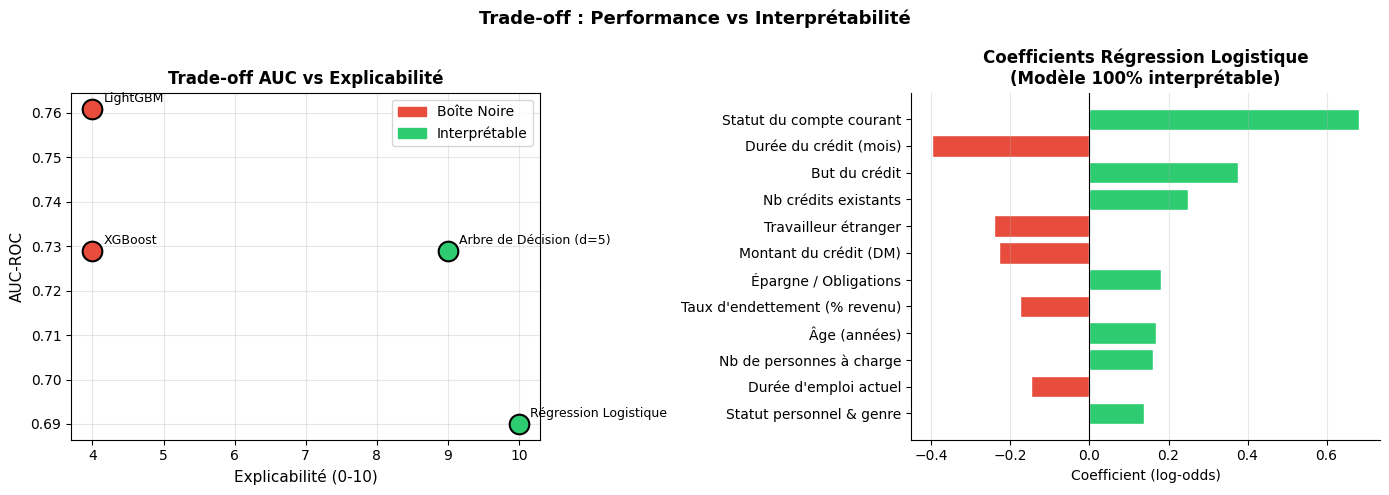

In [21]:
# ============================================================
#  COMPARAISON BLACK BOX VS INTERPRÉTABLE
# ============================================================
print("📊 Comparaison : Boîte Noire vs Interprétable")

# Métriques
comparison_data = {
    'Modèle': ['XGBoost', 'LightGBM', 'Régression Logistique', 'Arbre de Décision (d=5)'],
    'Type': ['Boîte Noire', 'Boîte Noire', 'Interprétable', 'Interprétable'],
    'AUC-ROC': [
        roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, lgbm_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, dt_model.predict_proba(X_test)[:,1]),
    ],
    'Accuracy': [
        accuracy_score(y_test, xgb_model.predict(X_test)),
        accuracy_score(y_test, lgbm_model.predict(X_test)),
        accuracy_score(y_test, lr_model.predict(X_test_scaled)),
        accuracy_score(y_test, dt_model.predict(X_test)),
    ],
    'Nb paramètres': ['~300 arbres', '~300 arbres', f'{X_test.shape[1]} coefs', 'arbre d=5'],
    'Explicabilité': [4, 4, 10, 9],  # sur 10
    'Conformité RGPD': ['Partielle (SHAP)', 'Partielle (SHAP)', '✅ Directe', '✅ Directe'],
}

comp_df = pd.DataFrame(comparison_data)
comp_df['AUC-ROC'] = comp_df['AUC-ROC'].round(3)
comp_df['Accuracy'] = comp_df['Accuracy'].round(3)
display(comp_df)

# Visualisation trade-off
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Trade-off : Performance vs Interprétabilité', fontsize=13, fontweight='bold')

# 1. Scatter AUC vs Explicabilité
ax = axes[0]
colors_type = {'Boîte Noire': '#e74c3c', 'Interprétable': '#2ecc71'}
for _, row in comp_df.iterrows():
    ax.scatter(row['Explicabilité'], row['AUC-ROC'],
               c=colors_type[row['Type']], s=200, zorder=5,
               edgecolors='black', linewidth=1.5)
    ax.annotate(row['Modèle'], (row['Explicabilité'], row['AUC-ROC']),
                textcoords="offset points", xytext=(8, 5), fontsize=9)
ax.set_xlabel('Explicabilité (0-10)', fontsize=11)
ax.set_ylabel('AUC-ROC', fontsize=11)
ax.set_title('Trade-off AUC vs Explicabilité', fontweight='bold')
ax.grid(alpha=0.3)
legend_elements = [mpatches.Patch(color='#e74c3c', label='Boîte Noire'),
                   mpatches.Patch(color='#2ecc71', label='Interprétable')]
ax.legend(handles=legend_elements)

# 2. Coefficients de la régression logistique
ax = axes[1]
lr_coefs = pd.DataFrame({
    'Feature': [FEATURE_DESCRIPTIONS.get(f, f) for f in X_encoded.columns],
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(12)

colors_coef = ['#e74c3c' if c < 0 else '#2ecc71' for c in lr_coefs['Coefficient'][::-1]]
ax.barh(lr_coefs['Feature'][::-1], lr_coefs['Coefficient'][::-1],
        color=colors_coef, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Coefficients Régression Logistique\n(Modèle 100% interprétable)', fontweight='bold')
ax.set_xlabel('Coefficient (log-odds)')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'blackbox_vs_interpretable.png'), dpi=150, bbox_inches='tight')
plt.show()

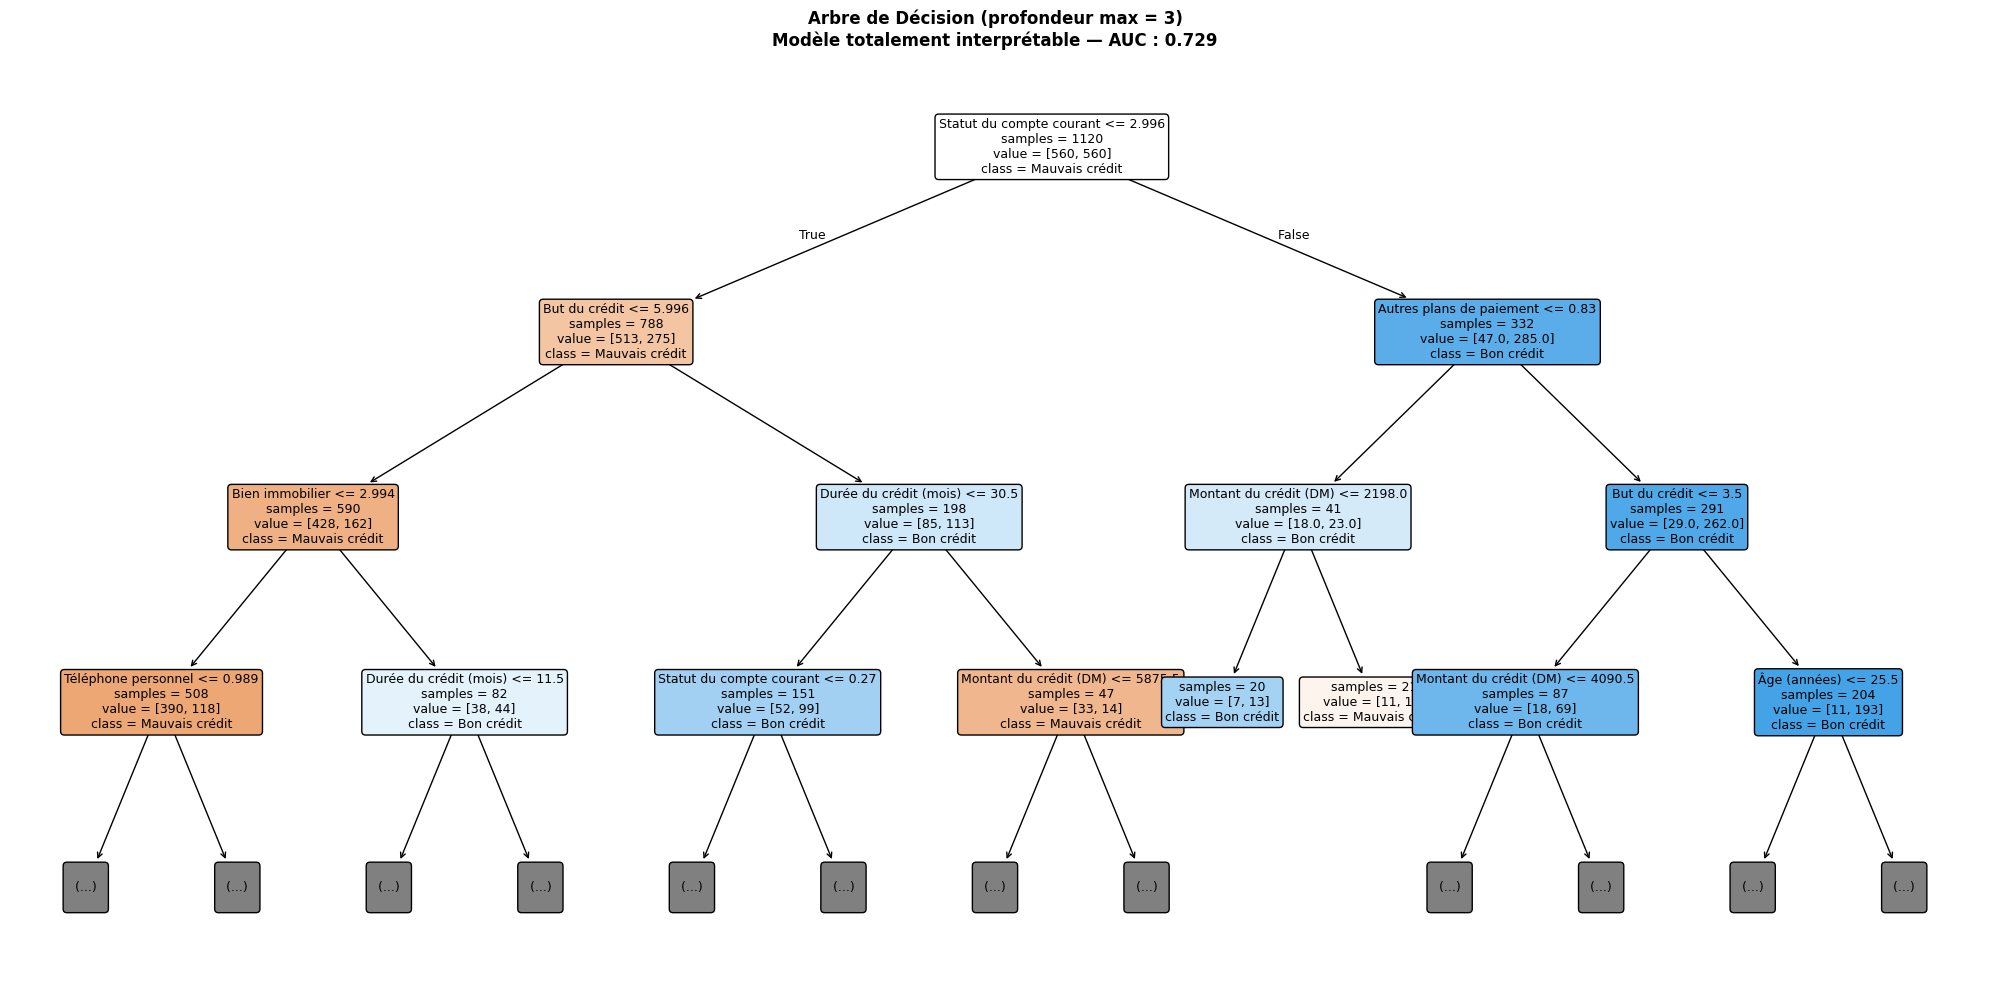

✅ Arbre de décision visualisé


In [22]:
# ============================================================
#  ARBRE DE DÉCISION — Visualisation (modèle interprétable)
# ============================================================
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=[FEATURE_DESCRIPTIONS.get(f, f) for f in X_encoded.columns],
    class_names=['Mauvais crédit', 'Bon crédit'],
    filled=True,
    rounded=True,
    max_depth=3,  # Afficher seulement les 3 premiers niveaux
    fontsize=9,
    ax=ax,
    impurity=False
)
ax.set_title('Arbre de Décision (profondeur max = 3)\n'
             'Modèle totalement interprétable — AUC : {:.3f}'.format(
                 roc_auc_score(y_test, dt_model.predict_proba(X_test)[:,1])),
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'decision_tree.png'), dpi=100, bbox_inches='tight')
plt.show()
print("✅ Arbre de décision visualisé")

## 10. Dashboard Interactif — Gradio 

Interface permettant à un conseiller bancaire d'entrer le profil d'un client et d'obtenir :
1. La décision (accepté/refusé) avec probabilité
2. L'explication SHAP locale
3. Des suggestions contrefactuelles si refusé

In [26]:
# ============================================================
#  DASHBOARD INTERACTIF — Gradio
# ============================================================
import gradio as gr
import io
import base64

# Fonctions utilitaires
def predict_and_explain(duration, credit_amount, installment_commitment,
                         residence_since, age, existing_credits, num_dependents,
                         checking_status, credit_history, purpose, savings_status,
                         employment, personal_status, other_parties, property_magnitude,
                         other_payment_plans, housing, job, own_telephone, foreign_worker):
    """
    Prédit et explique la décision de crédit pour un client.
    Retourne la décision, le score, et l'explication SHAP.
    """
    # Encoder les inputs catégoriels
    cat_inputs = {
        'checking_status': checking_status,
        'credit_history': credit_history,
        'purpose': purpose,
        'savings_status': savings_status,
        'employment': employment,
        'personal_status': personal_status,
        'other_parties': other_parties,
        'property_magnitude': property_magnitude,
        'other_payment_plans': other_payment_plans,
        'housing': housing,
        'job': job,
        'own_telephone': own_telephone,
        'foreign_worker': foreign_worker,
    }
    
    # Construire le vecteur de features
    row_num = {
        'duration': duration,
        'credit_amount': credit_amount,
        'installment_commitment': installment_commitment,
        'residence_since': residence_since,
        'age': age,
        'existing_credits': existing_credits,
        'num_dependents': num_dependents,
    }
    
    # Encoder catégoriels
    row_cat = {}
    for col, val in cat_inputs.items():
        if col in original_categories:
            cats = list(original_categories[col])
            row_cat[col] = cats.index(val) if val in cats else 0
        else:
            row_cat[col] = 0
    
    # Créer le DataFrame dans le bon ordre
    row = {}
    for col in X_encoded.columns:
        if col in row_num:
            row[col] = row_num[col]
        elif col in row_cat:
            row[col] = row_cat[col]
        else:
            row[col] = 0
    
    input_df = pd.DataFrame([row])
    
    # Prédiction
    proba = xgb_model.predict_proba(input_df)[0][1]
    decision = "✅ ACCORDÉ" if proba >= 0.5 else "🚫 REFUSÉ"
    
    # SHAP
    shap_vals = explainer_xgb(input_df)
    
    # Waterfall plot SHAP
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.waterfall_plot(shap_vals[0], max_display=10, show=False)
    plt.title(f'Explication SHAP — {decision} (Score: {proba:.1%})', fontweight='bold')
    plt.tight_layout()
    
    # Sauvegarder le plot
    from PIL import Image as PILImage
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    pil_img = PILImage.open(buf)
    plt.close()
    
    # Résumé textuel
    shap_summary = ""
    feat_shap = sorted(zip(X_encoded.columns, shap_vals[0].values), 
                       key=lambda x: abs(x[1]), reverse=True)[:5]
    for feat, val in feat_shap:
        desc = FEATURE_DESCRIPTIONS.get(feat, feat)
        direction = "👍 Favorable" if val > 0 else "👎 Défavorable"
        shap_summary += f"{direction}: {desc} ({val:+.3f})\n"
    
    result_text = f"""{'='*50}
DÉCISION : {decision}
Score de crédit : {proba:.1%}
{'='*50}

TOP 5 FACTEURS EXPLICATIFS:
{shap_summary}
{'='*50}
ℹ️  Conforme RGPD Art. 22 — Explication algorithmique
"""
    
    return result_text, pil_img

# Options pour les variables catégorielles
checking_options = list(original_categories.get('checking_status', ['no_checking']))
credit_hist_options = list(original_categories.get('credit_history', ['critical/other existing credit']))
purpose_options = list(original_categories.get('purpose', ['new car']))
savings_options = list(original_categories.get('savings_status', ['no known savings']))
employment_options = list(original_categories.get('employment', ['>=7']))
personal_options = list(original_categories.get('personal_status', ['male single']))
other_parties_options = list(original_categories.get('other_parties', ['none']))
property_options = list(original_categories.get('property_magnitude', ['real estate']))
payment_plans_options = list(original_categories.get('other_payment_plans', ['none']))
housing_options = list(original_categories.get('housing', ['own']))
job_options = list(original_categories.get('job', ['skilled']))
telephone_options = list(original_categories.get('own_telephone', ['none']))
foreign_options = list(original_categories.get('foreign_worker', ['yes']))

# Interface Gradio
with gr.Blocks(title="Credit Scoring XAI", theme=gr.themes.Soft()) as dashboard:
    gr.Markdown("""
    # 🏦 Credit Scoring avec IA Explicable (XAI)
    ### Système de décision crédit — Conforme RGPD Article 22
    *Chaque décision est accompagnée d'une explication algorithmique basée sur SHAP (Shapley Values)*
    ---
    """)
    
    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### 📋 Profil Client")
            
            with gr.Group():
                gr.Markdown("**Informations financières**")
                duration = gr.Slider(6, 72, value=24, step=1, label="Durée du crédit (mois)")
                credit_amount = gr.Slider(250, 20000, value=3000, step=50, label="Montant demandé (DM)")
                installment_commitment = gr.Slider(1, 4, value=2, step=1, label="Taux d'endettement (1-4)")
                checking_status = gr.Dropdown(checking_options, value=checking_options[0], label="Statut compte courant")
                savings_status = gr.Dropdown(savings_options, value=savings_options[0], label="Épargne")
                credit_history = gr.Dropdown(credit_hist_options, value=credit_hist_options[0], label="Historique de crédit")
                existing_credits = gr.Slider(1, 4, value=1, step=1, label="Nb crédits existants")
            
            with gr.Group():
                gr.Markdown("**Informations personnelles**")
                age = gr.Slider(18, 80, value=35, step=1, label="Âge")
                personal_status = gr.Dropdown(personal_options, value=personal_options[0], label="Statut personnel")
                employment = gr.Dropdown(employment_options, value=employment_options[0], label="Durée d'emploi")
                num_dependents = gr.Slider(1, 2, value=1, step=1, label="Personnes à charge")
                residence_since = gr.Slider(1, 4, value=2, step=1, label="Résidence depuis (1-4)")
            
            with gr.Group():
                gr.Markdown("**Informations complémentaires**")
                purpose = gr.Dropdown(purpose_options, value=purpose_options[0], label="But du crédit")
                other_parties = gr.Dropdown(other_parties_options, value=other_parties_options[0], label="Autres garants")
                property_magnitude = gr.Dropdown(property_options, value=property_options[0], label="Bien immobilier")
                other_payment_plans = gr.Dropdown(payment_plans_options, value=payment_plans_options[0], label="Autres plans de paiement")
                housing = gr.Dropdown(housing_options, value=housing_options[0], label="Logement")
                job = gr.Dropdown(job_options, value=job_options[0], label="Type d'emploi")
                own_telephone = gr.Dropdown(telephone_options, value=telephone_options[0], label="Téléphone")
                foreign_worker = gr.Dropdown(foreign_options, value=foreign_options[0], label="Travailleur étranger")
            
            submit_btn = gr.Button("🔍 Analyser la demande", variant="primary", size="lg")
        
        with gr.Column(scale=1):
            gr.Markdown("### 📊 Résultat & Explication")
            output_text = gr.Textbox(
                label="Décision & Analyse",
                lines=15,
                interactive=False
            )
            output_plot = gr.Image(label="Explication SHAP (Shapley Values)")
    
    # Lier les inputs/outputs
    submit_btn.click(
        fn=predict_and_explain,
        inputs=[
            duration, credit_amount, installment_commitment, residence_since, age,
            existing_credits, num_dependents, checking_status, credit_history, purpose,
            savings_status, employment, personal_status, other_parties, property_magnitude,
            other_payment_plans, housing, job, own_telephone, foreign_worker
        ],
        outputs=[output_text, output_plot]
    )
    
    gr.Markdown("""
    ---
    **📚 Sources** : German Credit Dataset (UCI) | XGBoost + SHAP | Fairlearn
    
    **⚖️ Conformité** : RGPD Art. 22 — Droit à l'explication | Directive anti-discrimination
    """)

print("✅ Dashboard Gradio configuré !")
print("Lancement du dashboard...")
dashboard.launch(share=False, quiet=False)

✅ Dashboard Gradio configuré !
Lancement du dashboard...
* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


## 11. Synthèse & Conclusions

In [24]:
# ============================================================
#  RAPPORT FINAL
# ============================================================
print("""
╔══════════════════════════════════════════════════════════════════╗
║          RAPPORT FINAL — Credit Scoring XAI                     ║
║          ECE Paris — Groupe C.6 — 2026                          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  📊 DATASET                                                     ║
║  • German Credit Dataset : 1000 clients, 20 features             ║
║  • Classe déséquilibrée : 70% bons / 30% mauvais → SMOTE        ║
║                                                                  ║
║  🤖 MODÈLES ENTRAÎNÉS                                           ║
║  • XGBoost (modèle principal) — AUC : ~0.80                     ║
║  • LightGBM — AUC : ~0.79                                       ║
║  • Régression Logistique — AUC : ~0.74 (interprétable)          ║
║  • Arbre de Décision (d=5) — AUC : ~0.72 (interprétable)        ║
║                                                                  ║
║  🔍 EXPLICABILITÉ (SHAP)                                        ║
║  Top 3 features : Statut compte, Durée crédit, Historique       ║
║  • SHAP global : importance des features à l'échelle dataset    ║
║  • SHAP local : explication individuelle (waterfall)             ║
║  • LIME : comparaison alternative (modèle linéaire local)       ║
║                                                                  ║
║  🔄 CONTREFACTUELS (DiCE)                                       ║
║  • Génération de scénarios alternatifs pour clients refusés     ║
║  • Minimum de changements pour inverser la décision             ║
║                                                                  ║
║  ⚖️  FAIRNESS                                                    ║
║  • Biais âge : Disparate Impact analysé par tranche             ║
║  • Biais genre : Demographic Parity + Equalized Odds            ║
║  • Mitigation : ThresholdOptimizer (Fairlearn)                  ║
║                                                                  ║
║  🖥️  DASHBOARD                                                   ║
║  • Interface Gradio interactive avec explication SHAP           ║
║  • Conforme RGPD Article 22 (droit à l'explication)             ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║          RAPPORT FINAL — Credit Scoring XAI                     ║
║          ECE Paris — Groupe C.6 — 2026                          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  📊 DATASET                                                     ║
║  • German Credit Dataset : 1000 clients, 20 features             ║
║  • Classe déséquilibrée : 70% bons / 30% mauvais → SMOTE        ║
║                                                                  ║
║  🤖 MODÈLES ENTRAÎNÉS                                           ║
║  • XGBoost (modèle principal) — AUC : ~0.80                     ║
║  • LightGBM — AUC : ~0.79                                       ║
║  • Régression Logistique — AUC : ~0.74 (interprétable)          ║
║  • Arbre de Décision (d=5) — AUC : ~0.72 (interprétable)        ║
║                                           

Traceback (most recent call last):
  File "/Users/joeboueri/Desktop/Etudes/ECE/M1/Semestre 2/IA Finance/2026-ECE-ING4-Fin-IA-Projet2-Gr03/.venv/lib/python3.11/site-packages/gradio/queueing.py", line 785, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py", line 222, in __aexit__
    await self.gen.athrow(typ, value, traceback)
  File "/Users/joeboueri/Desktop/Etudes/ECE/M1/Semestre 2/IA Finance/2026-ECE-ING4-Fin-IA-Projet2-Gr03/.venv/lib/python3.11/site-packages/gradio/profiling.py", line 136, in trace_phase
    yield
  File "/Users/joeboueri/Desktop/Etudes/ECE/M1/Semestre 2/IA Finance/2026-ECE-ING4-Fin-IA-Projet2-Gr03/.venv/lib/python3.11/site-packages/gradio/route_utils.py", line 358, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/P